In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

base = "/content/drive/MyDrive/College_Financial_Distress_Model"

model_data = pd.read_csv(
    f"{base}/processed_data/college_closure_model_data.csv"
)

print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))
print("Closures:", model_data["CLOSED_WITHIN_3Y"].sum())

display(model_data.head())

Mounted at /content/drive
Rows: 3493
Columns: 94
Closures: 75


,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,...,DEGREE_GRANTING,HAS_CORE_FINANCIALS,LIABILITIES_TO_ASSETS_W,OPERATING_MARGIN_W,TUITION_DEPENDENCE_W,ENROLLMENT_CHANGE_2019_2022_W,TUITION_DEPENDENCE_AUDITED,TUITION_DEPENDENCE_AUDITED_W,PREDICTED_CLOSURE_PROB,OPEID_MATCH
0,100654,Alabama A & M University,AAMU,4900 Meridian Street,Normal,AL,35762,1,5,Dr. Daniel K. Wims,...,True,True,0.554822,-0.029086,0.246619,-0.026734,0.246619,0.246619,0.000461,100200
1,100663,University of Alabama at Birmingham,UAB,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,...,True,True,0.584393,-0.105892,0.065972,-0.019973,0.065972,0.065972,0.000661,105200
2,100690,Amridge University,Southern Christian University Regions University,1200 Taylor Rd,Montgomery,AL,36117-3553,1,5,Michael C.Turner,...,True,True,0.059527,0.021143,0.973875,-0.223289,0.973875,0.973875,0.014193,2503400
3,100706,University of Alabama in Huntsville,UAH University of Alabama Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Chuck Karr,...,True,True,0.733214,0.067816,0.230584,-0.075190,0.230584,0.230584,0.000595,105500
4,100724,Alabama State University,,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Quinton T. Ross,...,True,True,0.490958,0.065004,0.206212,-0.086396,0.206212,0.206212,0.000562,100500


In [2]:
# ==========================================
# 2. DEFINE FINAL MODEL
# ==========================================

import statsmodels.formula.api as smf

# Variables used in the final early-warning model
model_vars = [
    "CLOSED_WITHIN_3Y",
    "FINANCE_SECTOR",
    "LIABILITIES_TO_ASSETS_W",
    "OPERATING_MARGIN_W",
    "TUITION_DEPENDENCE_AUDITED_W",
    "ENROLLMENT_CHANGE_2019_2022_W"
]

df = model_data[model_vars].dropna().copy()

print("Final modeling sample:")
print("Institutions:", len(df))
print("Closures:", int(df["CLOSED_WITHIN_3Y"].sum()))
print("\nInstitutions by sector:")
print(df["FINANCE_SECTOR"].value_counts())

Final modeling sample:
Institutions: 3493
Closures: 75

Institutions by sector:
FINANCE_SECTOR
Private nonprofit    1565
Public               1430
For-profit            498
Name: count, dtype: int64


In [3]:
# ==========================================
# 3. FIT FINAL LOGISTIC REGRESSION
# ==========================================

formula = """
CLOSED_WITHIN_3Y ~
C(FINANCE_SECTOR) +
LIABILITIES_TO_ASSETS_W +
OPERATING_MARGIN_W +
TUITION_DEPENDENCE_AUDITED_W +
ENROLLMENT_CHANGE_2019_2022_W
"""

final_model = smf.logit(
    formula=formula,
    data=df
).fit()

print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.082227
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:       CLOSED_WITHIN_3Y   No. Observations:                 3493
Model:                          Logit   Df Residuals:                     3486
Method:                           MLE   Df Model:                            6
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                  0.2072
Time:                        21:50:20   Log-Likelihood:                -287.22
converged:                       True   LL-Null:                       -362.27
Covariance Type:            nonrobust   LLR p-value:                 7.387e-30
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -1.8594  

In [4]:
# ==========================================
# 4. INTERPRETABLE EFFECT SIZES
# ==========================================

import numpy as np
import pandas as pd

effects = pd.DataFrame({
    "Predictor": [
        "Enrollment change",
        "Liabilities / assets",
        "Operating margin",
        "Tuition dependence"
    ],
    "Coefficient": [
        final_model.params["ENROLLMENT_CHANGE_2019_2022_W"],
        final_model.params["LIABILITIES_TO_ASSETS_W"],
        final_model.params["OPERATING_MARGIN_W"],
        final_model.params["TUITION_DEPENDENCE_AUDITED_W"]
    ],
    "p_value": [
        final_model.pvalues["ENROLLMENT_CHANGE_2019_2022_W"],
        final_model.pvalues["LIABILITIES_TO_ASSETS_W"],
        final_model.pvalues["OPERATING_MARGIN_W"],
        final_model.pvalues["TUITION_DEPENDENCE_AUDITED_W"]
    ]
})

# Odds ratio associated with a 10-percentage-point increase
effects["Odds_ratio_per_10pp_increase"] = np.exp(
    effects["Coefficient"] * 0.10
)

effects["Odds_change_pct"] = (
    effects["Odds_ratio_per_10pp_increase"] - 1
) * 100

display(effects.round(4))

# Enrollment DECLINE is easier to interpret in the opposite direction
enrollment_decline_or = np.exp(
    -final_model.params["ENROLLMENT_CHANGE_2019_2022_W"] * 0.10
)

print(
    f"\nA 10-percentage-point larger enrollment decline "
    f"is associated with {enrollment_decline_or:.3f}x the odds of closure "
    f"({(enrollment_decline_or - 1) * 100:.1f}% higher odds), "
    f"holding the other model variables constant."
)

,Predictor,Coefficient,p_value,Odds_ratio_per_10pp_increase,Odds_change_pct
0,Enrollment change,-3.2121,0.0000,0.7253,-27.4732
1,Liabilities / assets,0.5784,0.0172,1.0595,5.9544
2,Operating margin,-0.3576,0.2920,0.9649,-3.5131
3,Tuition dependence,-1.8633,0.0009,0.8300,-16.9996



A 10-percentage-point larger enrollment decline is associated with 1.379x the odds of closure (37.9% higher odds), holding the other model variables constant.


In [5]:
# ==========================================
# 5. 5-FOLD OUT-OF-SAMPLE VALIDATION
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

features = [
    "FINANCE_SECTOR",
    "LIABILITIES_TO_ASSETS_W",
    "OPERATING_MARGIN_W",
    "TUITION_DEPENDENCE_AUDITED_W",
    "ENROLLMENT_CHANGE_2019_2022_W"
]

X = df[features].copy()
y = df["CLOSED_WITHIN_3Y"].astype(int)

categorical_features = ["FINANCE_SECTOR"]

numeric_features = [
    "LIABILITIES_TO_ASSETS_W",
    "OPERATING_MARGIN_W",
    "TUITION_DEPENDENCE_AUDITED_W",
    "ENROLLMENT_CHANGE_2019_2022_W"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "sector",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        ),
        ("numeric", "passthrough", numeric_features)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oos_prob = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

roc_auc = roc_auc_score(y, oos_prob)
pr_auc = average_precision_score(y, oos_prob)
baseline = y.mean()

print("=== 5-FOLD OUT-OF-SAMPLE PERFORMANCE ===")
print(f"Institutions: {len(y)}")
print(f"Closures: {y.sum()}")
print()
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Random PR baseline: {baseline:.4f}")
print(f"PR lift: {pr_auc / baseline:.1f}x")

=== 5-FOLD OUT-OF-SAMPLE PERFORMANCE ===
Institutions: 3493
Closures: 75

ROC-AUC: 0.8568
PR-AUC: 0.1039
Random PR baseline: 0.0215
PR lift: 4.8x


In [6]:
# ==========================================
# 6. COMPARE PREDICTIVE INFORMATION
# ==========================================

models = {
    "Sector only": [
        "FINANCE_SECTOR"
    ],

    "Financials only": [
        "LIABILITIES_TO_ASSETS_W",
        "OPERATING_MARGIN_W",
        "TUITION_DEPENDENCE_AUDITED_W"
    ],

    "Sector + enrollment": [
        "FINANCE_SECTOR",
        "ENROLLMENT_CHANGE_2019_2022_W"
    ],

    "Full model": [
        "FINANCE_SECTOR",
        "LIABILITIES_TO_ASSETS_W",
        "OPERATING_MARGIN_W",
        "TUITION_DEPENDENCE_AUDITED_W",
        "ENROLLMENT_CHANGE_2019_2022_W"
    ]
}

comparison_results = []

for name, vars_used in models.items():

    categorical = [
        col for col in vars_used
        if col == "FINANCE_SECTOR"
    ]

    numeric = [
        col for col in vars_used
        if col != "FINANCE_SECTOR"
    ]

    transformers = []

    if categorical:
        transformers.append(
            (
                "sector",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ),
                categorical
            )
        )

    if numeric:
        transformers.append(
            ("numeric", "passthrough", numeric)
        )

    prep = ColumnTransformer(
        transformers=transformers
    )

    pipe = Pipeline([
        ("preprocessor", prep),
        ("model", LogisticRegression(max_iter=2000))
    ])

    probs = cross_val_predict(
        pipe,
        df[vars_used],
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    comparison_results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y, probs),
        "PR_AUC": average_precision_score(y, probs)
    })

model_comparison = pd.DataFrame(comparison_results)

display(
    model_comparison.round(4)
)

,Model,ROC_AUC,PR_AUC
0,Sector only,0.7197,0.0418
1,Financials only,0.6725,0.0350
2,Sector + enrollment,0.8437,0.1000
3,Full model,0.8568,0.1039


In [7]:
# ==========================================
# 7. OUT-OF-SAMPLE RISK CONCENTRATION
# ==========================================

risk_results = df.copy()

# Every institution receives its out-of-sample
# probability from the 5-fold validation
risk_results["OOS_CLOSURE_RISK"] = oos_prob

# Rank from highest to lowest predicted risk
risk_results = risk_results.sort_values(
    "OOS_CLOSURE_RISK",
    ascending=False
).reset_index(drop=True)

total_n = len(risk_results)
total_closures = int(risk_results["CLOSED_WITHIN_3Y"].sum())

summary = []

for pct in [0.05, 0.10, 0.20]:

    n = int(np.ceil(total_n * pct))
    group = risk_results.head(n)

    closures = int(group["CLOSED_WITHIN_3Y"].sum())
    closure_rate = group["CLOSED_WITHIN_3Y"].mean()
    overall_rate = total_closures / total_n

    summary.append({
        "Highest-risk group": f"Top {int(pct*100)}%",
        "Institutions": n,
        "Closures": closures,
        "Closure rate": closure_rate,
        "Share of closures captured": closures / total_closures,
        "Risk multiple vs overall": closure_rate / overall_rate
    })

risk_summary = pd.DataFrame(summary)

display(
    risk_summary.style.format({
        "Closure rate": "{:.2%}",
        "Share of closures captured": "{:.2%}",
        "Risk multiple vs overall": "{:.2f}x"
    })
)

print(f"Overall closure rate: {overall_rate:.2%}")

,Highest-risk group,Institutions,Closures,Closure rate,Share of closures captured,Risk multiple vs overall
0,Top 5%,175,21,12.00%,28.00%,5.59x
1,Top 10%,350,40,11.43%,53.33%,5.32x
2,Top 20%,699,55,7.87%,73.33%,3.66x


Overall closure rate: 2.15%


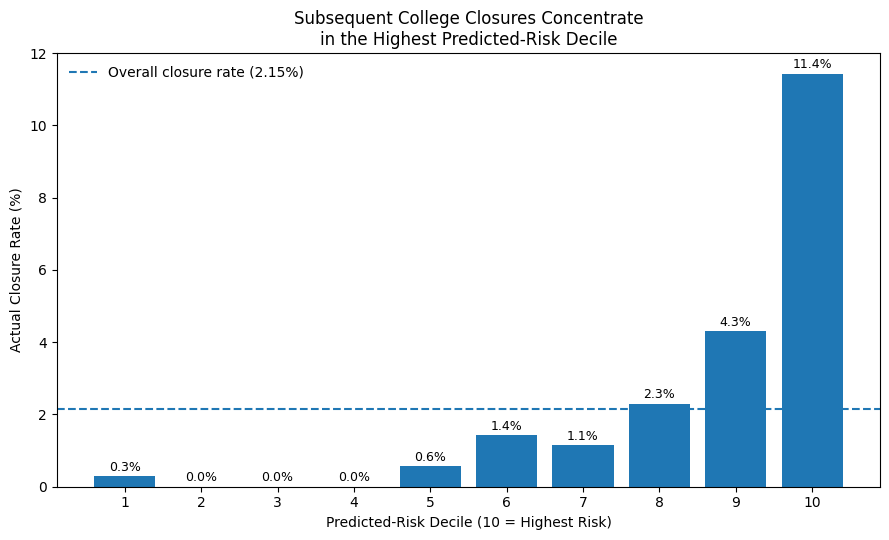

,RISK_DECILE,Institutions,Closures,Closure_Rate,Closure_Rate_Pct
0,1,350,1,0.0029,0.2857
1,2,349,0,0.0000,0.0000
2,3,349,0,0.0000,0.0000
3,4,349,0,0.0000,0.0000
4,5,350,2,0.0057,0.5714
5,6,349,5,0.0143,1.4327
6,7,349,4,0.0115,1.1461
7,8,349,8,0.0229,2.2923
8,9,349,15,0.0430,4.2980
9,10,350,40,0.1143,11.4286


In [8]:
# ==========================================
# 8. FIGURE 1 — CLOSURE RATE BY RISK DECILE
# ==========================================

import matplotlib.pyplot as plt

# Assign institutions to deciles using OOS predictions
risk_results["RISK_DECILE"] = pd.qcut(
    risk_results["OOS_CLOSURE_RISK"],
    10,
    labels=False,
    duplicates="drop"
) + 1

decile_results = (
    risk_results
    .groupby("RISK_DECILE", observed=True)
    .agg(
        Institutions=("CLOSED_WITHIN_3Y", "size"),
        Closures=("CLOSED_WITHIN_3Y", "sum"),
        Closure_Rate=("CLOSED_WITHIN_3Y", "mean")
    )
    .reset_index()
)

decile_results["Closure_Rate_Pct"] = (
    decile_results["Closure_Rate"] * 100
)

overall_pct = y.mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    decile_results["RISK_DECILE"],
    decile_results["Closure_Rate_Pct"]
)

ax.axhline(
    overall_pct,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall closure rate ({overall_pct:.2f}%)"
)

ax.set_xlabel("Predicted-Risk Decile (10 = Highest Risk)")
ax.set_ylabel("Actual Closure Rate (%)")

ax.set_title(
    "Subsequent College Closures Concentrate\n"
    "in the Highest Predicted-Risk Decile"
)

ax.set_xticks(range(1, 11))

for bar, value in zip(
    bars,
    decile_results["Closure_Rate_Pct"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    f"{base}/outputs/closure_risk_deciles_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(decile_results.round(4))

/tmp/ipykernel_1264/258529121.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


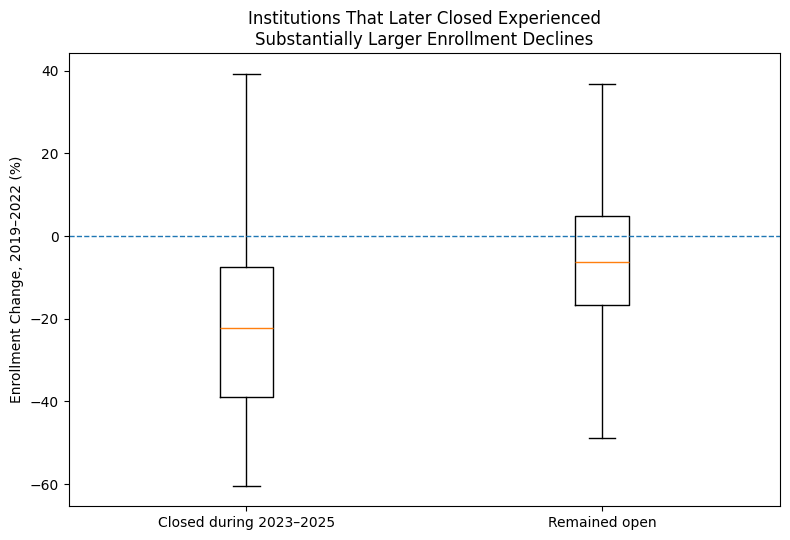

=== MEDIAN ENROLLMENT CHANGE ===
Closed institutions: -22.27%
Institutions remaining open: -6.24%
Difference: -16.03 percentage points


In [9]:
# ==========================================
# 9. FIGURE 2 — PRE-CLOSURE ENROLLMENT CHANGE
# ==========================================

plot_df = model_data[
    [
        "CLOSED_WITHIN_3Y",
        "ENROLLMENT_CHANGE_2019_2022_W"
    ]
].dropna().copy()

closed_enrollment = (
    plot_df.loc[
        plot_df["CLOSED_WITHIN_3Y"] == 1,
        "ENROLLMENT_CHANGE_2019_2022_W"
    ] * 100
)

open_enrollment = (
    plot_df.loc[
        plot_df["CLOSED_WITHIN_3Y"] == 0,
        "ENROLLMENT_CHANGE_2019_2022_W"
    ] * 100
)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.boxplot(
    [closed_enrollment, open_enrollment],
    labels=[
        "Closed during 2023–2025",
        "Remained open"
    ],
    showfliers=False
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_ylabel("Enrollment Change, 2019–2022 (%)")

ax.set_title(
    "Institutions That Later Closed Experienced\n"
    "Substantially Larger Enrollment Declines"
)

plt.tight_layout()

plt.savefig(
    f"{base}/outputs/enrollment_change_closure_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=== MEDIAN ENROLLMENT CHANGE ===")
print(
    f"Closed institutions: {closed_enrollment.median():.2f}%"
)
print(
    f"Institutions remaining open: {open_enrollment.median():.2f}%"
)
print(
    f"Difference: "
    f"{closed_enrollment.median() - open_enrollment.median():.2f} percentage points"
)

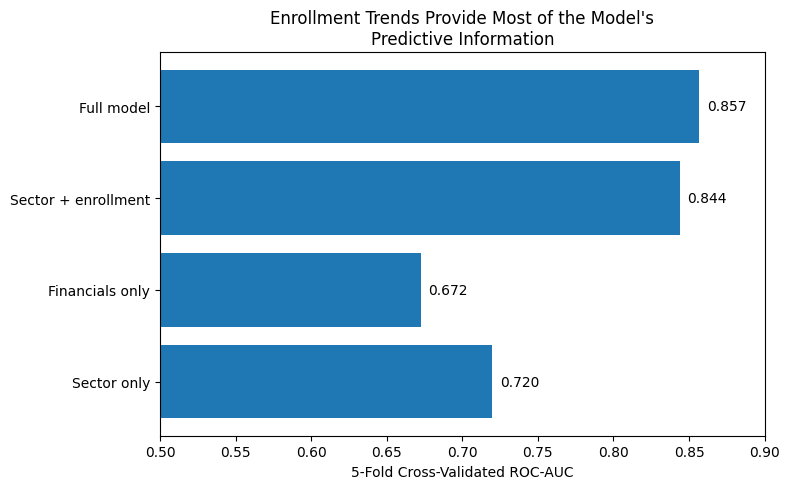

,Model,ROC_AUC,PR_AUC
0,Sector only,0.7197,0.0418
1,Financials only,0.6725,0.0350
2,Sector + enrollment,0.8437,0.1000
3,Full model,0.8568,0.1039


In [10]:
# ==========================================
# 10. FIGURE 3 — MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Sector only",
        "Financials only",
        "Sector + enrollment",
        "Full model"
    ],
    "ROC_AUC": [
        0.7197,
        0.6725,
        0.8437,
        0.8568
    ],
    "PR_AUC": [
        0.0418,
        0.0350,
        0.1000,
        0.1039
    ]
})

# Plot ROC-AUC
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    comparison["Model"],
    comparison["ROC_AUC"]
)

ax.set_xlim(0.5, 0.90)
ax.set_xlabel("5-Fold Cross-Validated ROC-AUC")

ax.set_title(
    "Enrollment Trends Provide Most of the Model's\n"
    "Predictive Information"
)

for bar, value in zip(bars, comparison["ROC_AUC"]):
    ax.text(
        value + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    f"{base}/outputs/model_comparison_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(comparison.round(4))